In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits


In [2]:
path = '/home/sophie-stucki/Documents/starsim_simulations/nina_spec/MPS-ATLAS_spectra/'
mps_quiet = np.load(path + 'av_solar_ssd_10_mu_angles.npy', allow_pickle=True).item()
mps_quiet_raw = np.load(path + 'solar_ssd_intencity_10_mu_angles.npy', allow_pickle=True).item()
mps_quiet_raw_new = np.load(path + 'solar_ssd_intencity_10_mu_angles_NEW.npy', allow_pickle=True).item()

phoenix_quiet = fits.open('/home/sophie-stucki/starsim/starsim/models/Phoenix_mu/lte05800-4.50-0.0.PHOENIX-ACES-AGSS-COND-SPECINT-2011.fits')[0].data


mps_fc = np.load(path + 'av_solar_faculae_10_mu_angles.npy', allow_pickle=True).item()

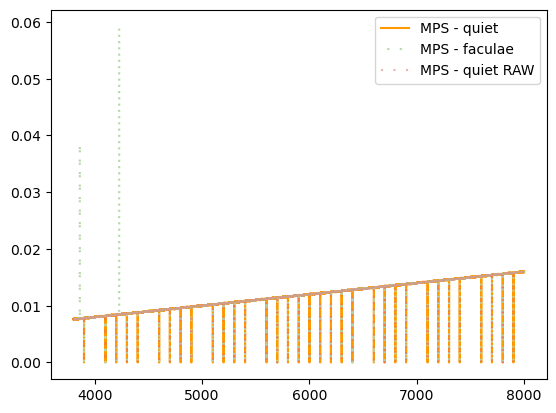

In [3]:
plt.plot(mps_quiet['1.0']['wav'][1:]*10, np.diff(mps_quiet['1.0']['wav']*10), label='MPS - quiet', color='#ff9900')
plt.plot(mps_fc['1.0']['wav'][1:]*10, np.diff(mps_fc['1.0']['wav']*10), linestyle= ((3, (1, 5))), label='MPS - faculae', color='#b6d7a8')
plt.plot(mps_quiet_raw['0.6']['wav'][1:]*10, np.diff(mps_quiet_raw['1.0']['wav']*10), linestyle= ((0, (1, 5))), label='MPS - quiet RAW', color='#eb6565', alpha=0.5)

plt.legend()

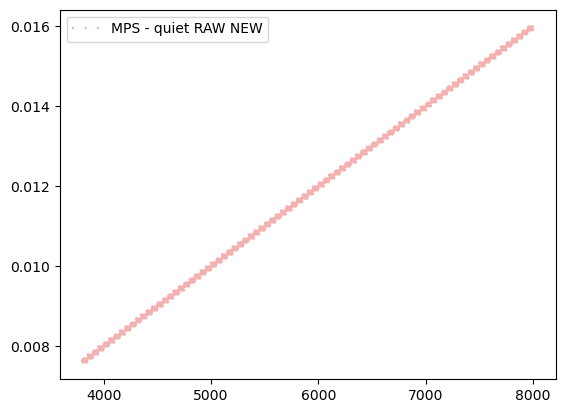

In [4]:
plt.plot(mps_quiet_raw_new['0.6']['wav'][1:]*10, np.diff(mps_quiet_raw_new['1.0']['wav']*10), linestyle= ((0, (1, 5))), label='MPS - quiet RAW NEW', color='#eb6565', alpha=0.5)
plt.legend()


In [6]:
import scipy.io as sio
from scipy.io import readsav
data_stagger = readsav('/home/sophie-stucki/Downloads/sun.sav')
lamba_stagger = data_stagger['data2'][0][1] 
flux_stagger = data_stagger['data2'][0][2]



/home/sophie-stucki/anaconda3/envs/starsim/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/sophie-stucki/anaconda3/envs/starsim/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


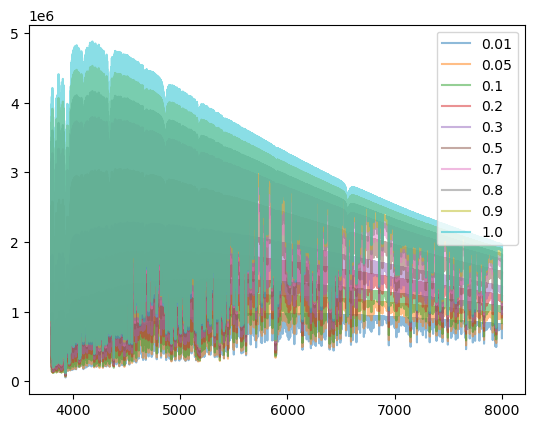

In [6]:
for mu in stagger_data.keys():
    plt.plot(stagger_data[mu]['wav'], stagger_data[mu]['intensity'], label = mu, alpha=0.5)
plt.legend()

In [7]:
mps_quiet_h = np.load('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/MPS-ATLAS_spectra/av_solar_ssd_200G_10_mu_angles_PHOENIX_high_res_grid_cleaned.npy', allow_pickle=True).item()
phoenix_quiet_h = fits.open('/home/sophie-stucki/starsim/starsim/models/Phoenix/lte05800-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits')[0].data
phoenix_wav = fits.open('/home/sophie-stucki/starsim/starsim/models/Phoenix/WAVE_PHOENIX-ACES-AGSS-COND-2011.fits')[0].data

In [8]:
from starsim import spectra
mask_name = '/home/sophie-stucki/starsim/starsim/masks/HARPS_G20_mps_friendly.mas'
mask = np.loadtxt(mask_name,unpack=True)
wvm = np.atleast_1d(spectra.air2vacuum((mask[0]+mask[1])/2)) #HARPS mask ar in air, not vacuum
fm = np.atleast_1d(mask[2])

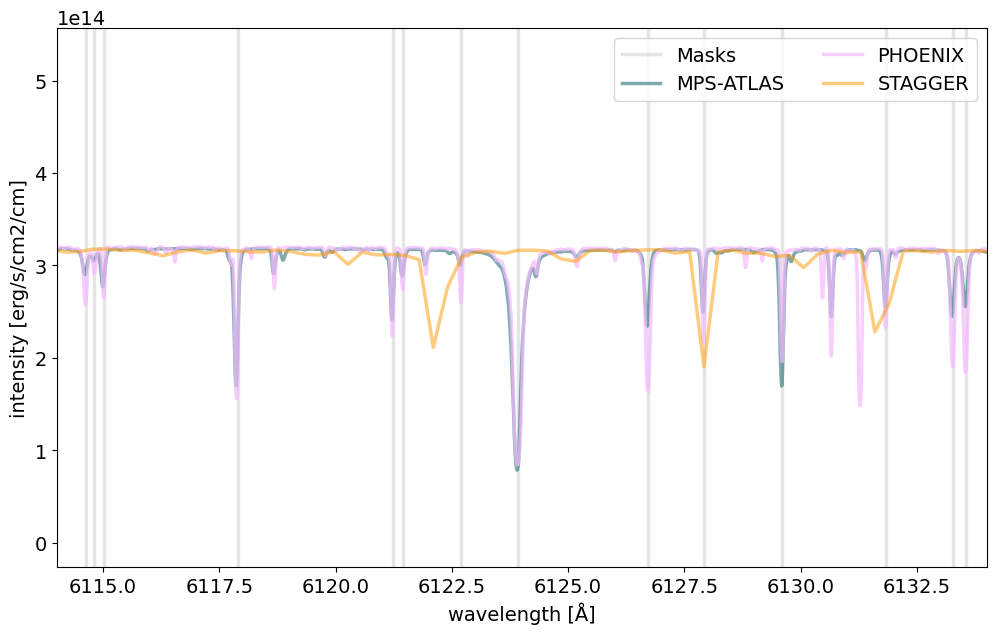

In [15]:
plt.rcParams['figure.figsize'] = (12,7)
plt.rcParams['font.size'] = 14

n = 7
plt.xlim(6121-n,6127+n)

for l in wvm:
    if l>6121-n and l<6127+n:
        harps_mask = plt.axvline(l,  color='#000000', alpha=0.1, linewidth=2.5)
mps_plot = plt.plot(mps_quiet_h['1.0']['wav'], mps_quiet_h['1.0']['intensity'] / ( 1e-8 * mps_quiet_h['1.0']['wav'])**2 * 2.99792458e10, alpha=0.5, color="#00595F", label='MPS-ATLAS', linewidth=2.5)
ph_plot = plt.plot(phoenix_wav, (phoenix_quiet_h) / 2.55, color="#f4baff", alpha=0.7, label='PHOENIX', linewidth=2.5) # erg/s/cm2/cm
stagger_plot = plt.plot(lamba_stagger,  flux_stagger[-1] * 1e8, label = 'STAGGER', alpha=0.5, color="#ff9900", linewidth=2.5) 



plt.legend(handles = [harps_mask, mps_plot[0], ph_plot[0], stagger_plot[0]], labels=['Masks', 'MPS-ATLAS', 'PHOENIX', 'STAGGER'], loc='upper right', ncols=2)
plt.xlabel('wavelength [Å]')
plt.ylabel('intensity [erg/s/cm2/cm]')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/3_spectra_comp.png')

IndexError: invalid index to scalar variable.

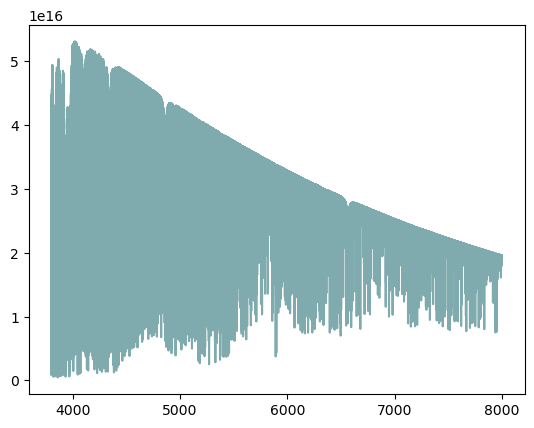

In [55]:
#TODO check at 6123.91 angstrom

plt.plot(mps_quiet['1.0']['wav'] * 10, mps_quiet['1.0']['intensity'] / ( 1e-8 * mps_quiet['1.0']['wav'])**2 * 2.99792458e10, alpha=0.5, color="#00595F", label='MPS-ATLAS')
plt.plot(np.arange(3801,8000), phoenix_quiet[-1][3301:7500], color="#f4baff", alpha=0.8, label='PHOENIX') # erg/s/cm2/cm
plt.plot(stagger_data[1.0]['wav'], stagger_data[1.0]['intensity'] * 1e8, label = 'STAGGER', alpha=0.5, color="#ff9900") 

plt.legend()
plt.xlabel('wavelength [Å]')
plt.ylabel('intensity []')
plt.savefig('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/3_spectra_comp.png')